# Problema 5 - Analisis de Redes Sociales

## Librerias

In [2]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

plt.rcParams["figure.figsize"] = (8, 6)

## (a) Cargar el grafo de red social

In [3]:
# Cargar grafo de red social predefinido
G = nx.karate_club_graph()

print("Grafo cargado correctamente.")

Grafo cargado correctamente.


## (b) Obtener informacion del grafo

In [4]:
num_nodos = G.number_of_nodes()
num_aristas = G.number_of_edges()

print("Numero de nodos:", num_nodos)
print("Numero de aristas:", num_aristas)

Numero de nodos: 34
Numero de aristas: 78


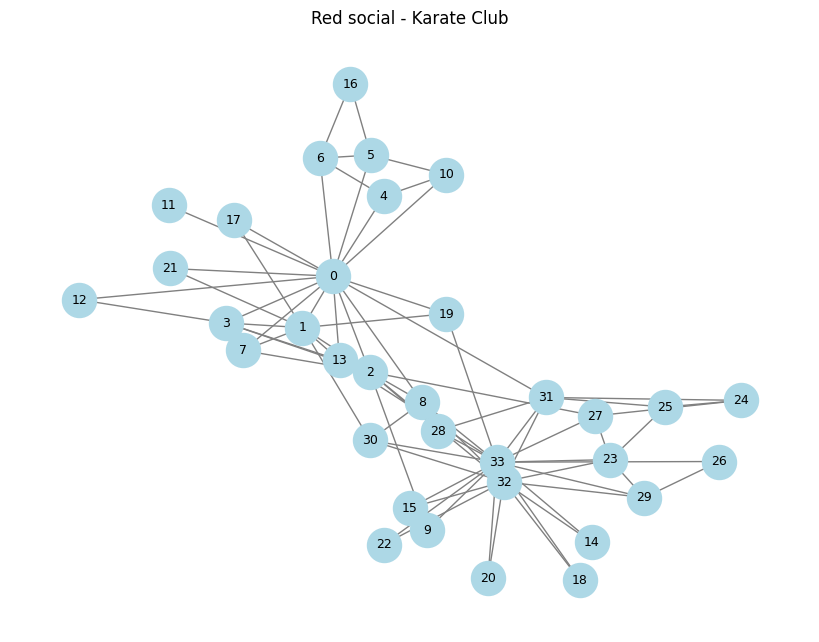

In [5]:
# Visualizacion basica del grafo
pos = nx.spring_layout(G, seed=42)

plt.figure()
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color="lightblue",
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Red social - Karate Club")
plt.show()

## (c) Tres formas distintas de definir un "influencer"

### 1. Un nodo se le considera influencer si tiene muchas conexiones directas.

### 2. Un nodo es influencer si sirve de puente entre distintos grupos de la red.

### 3. Un nodo es influencer si esta conectado con otros nodos importantes.

In [6]:
# Calcular centralidades
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
eigenvector_centrality = nx.eigenvector_centrality(G, max_iter=1000)

print("Centralidades calculadas.")

Centralidades calculadas.


In [7]:
# Mostrar los 5 nodos mas altos en cada metrica

top5_degree = sorted(degree_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top5_betweenness = sorted(betweenness_centrality.items(), key=lambda x: x[1], reverse=True)[:5]
top5_eigenvector = sorted(eigenvector_centrality.items(), key=lambda x: x[1], reverse=True)[:5]

print("Top 5 - Degree Centrality")
for nodo, valor in top5_degree:
    print(f"Nodo {nodo}: {valor:.4f}")

print("\nTop 5 - Betweenness Centrality")
for nodo, valor in top5_betweenness:
    print(f"Nodo {nodo}: {valor:.4f}")

print("\nTop 5 - Eigenvector Centrality")
for nodo, valor in top5_eigenvector:
    print(f"Nodo {nodo}: {valor:.4f}")

Top 5 - Degree Centrality
Nodo 33: 0.5152
Nodo 0: 0.4848
Nodo 32: 0.3636
Nodo 2: 0.3030
Nodo 1: 0.2727

Top 5 - Betweenness Centrality
Nodo 0: 0.4376
Nodo 33: 0.3041
Nodo 32: 0.1452
Nodo 2: 0.1437
Nodo 31: 0.1383

Top 5 - Eigenvector Centrality
Nodo 33: 0.3734
Nodo 0: 0.3555
Nodo 2: 0.3172
Nodo 32: 0.3087
Nodo 1: 0.2660


## (d) Encontrar el Top Influencer segun cada propuesta

In [8]:
top_degree = max(degree_centrality, key=degree_centrality.get)
top_betweenness = max(betweenness_centrality, key=betweenness_centrality.get)
top_eigenvector = max(eigenvector_centrality, key=eigenvector_centrality.get)

print("Top influencer segun Degree Centrality:", top_degree)
print("Top influencer segun Betweenness Centrality:", top_betweenness)
print("Top influencer segun Eigenvector Centrality:", top_eigenvector)

Top influencer segun Degree Centrality: 33
Top influencer segun Betweenness Centrality: 0
Top influencer segun Eigenvector Centrality: 33


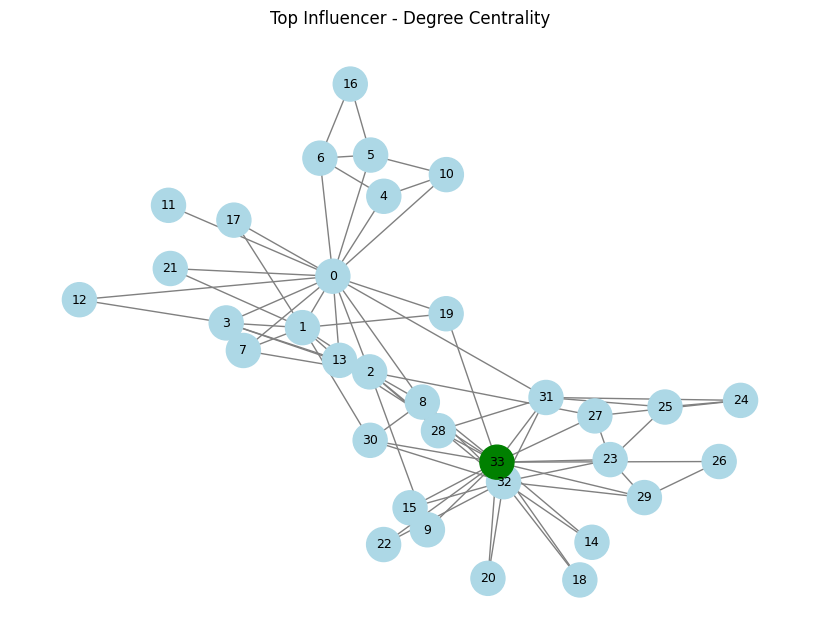

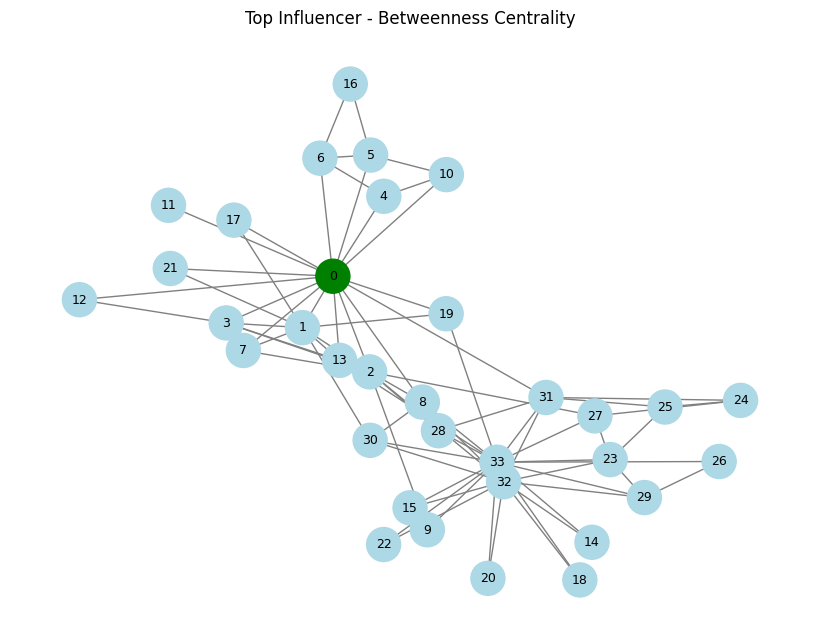

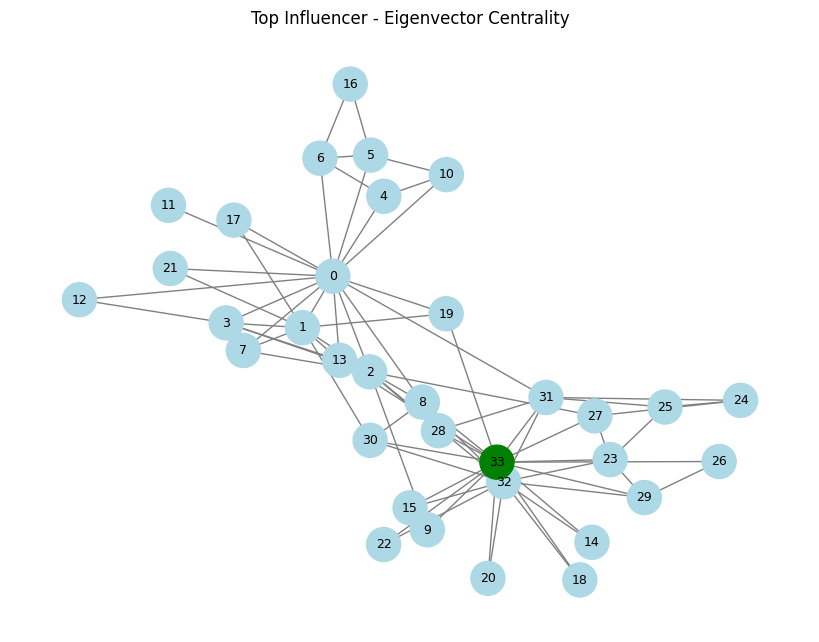

In [9]:
def dibujar_influencer(grafo, pos, influencer, titulo):
    colores = ["green" if n == influencer else "lightblue" for n in grafo.nodes()]
    plt.figure()
    nx.draw(
        grafo,
        pos,
        with_labels=True,
        node_color=colores,
        edge_color="gray",
        node_size=600,
        font_size=9
    )
    plt.title(titulo)
    plt.show()

dibujar_influencer(G, pos, top_degree, "Top Influencer - Degree Centrality")
dibujar_influencer(G, pos, top_betweenness, "Top Influencer - Betweenness Centrality")
dibujar_influencer(G, pos, top_eigenvector, "Top Influencer - Eigenvector Centrality")

## (e) Identificacion de comunidades

In [10]:
# Detectar comunidades usando particion codiciosa
communities = list(greedy_modularity_communities(G))

print("Numero de comunidades detectadas:", len(communities))
for i, comunidad in enumerate(communities, start=1):
    print(f"Comunidad {i} (tamaño {len(comunidad)}): {sorted(comunidad)}")

Numero de comunidades detectadas: 3
Comunidad 1 (tamaño 17): [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Comunidad 2 (tamaño 9): [1, 2, 3, 7, 9, 12, 13, 17, 21]
Comunidad 3 (tamaño 8): [0, 4, 5, 6, 10, 11, 16, 19]


In [11]:
# Mostrar solo comunidades de tamano 3, 4 y 5 o mas
print("Clasificacion por tamaño:\n")

for i, comunidad in enumerate(communities, start=1):
    tam = len(comunidad)
    if tam == 3:
        print(f"Comunidad {i}: tamaño 3 -> {sorted(comunidad)}")
    elif tam == 4:
        print(f"Comunidad {i}: tamaño 4 -> {sorted(comunidad)}")
    elif tam >= 5:
        print(f"Comunidad {i}: tamaño 5 o mas -> {sorted(comunidad)}")

Clasificacion por tamaño:

Comunidad 1: tamaño 5 o mas -> [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
Comunidad 2: tamaño 5 o mas -> [1, 2, 3, 7, 9, 12, 13, 17, 21]
Comunidad 3: tamaño 5 o mas -> [0, 4, 5, 6, 10, 11, 16, 19]


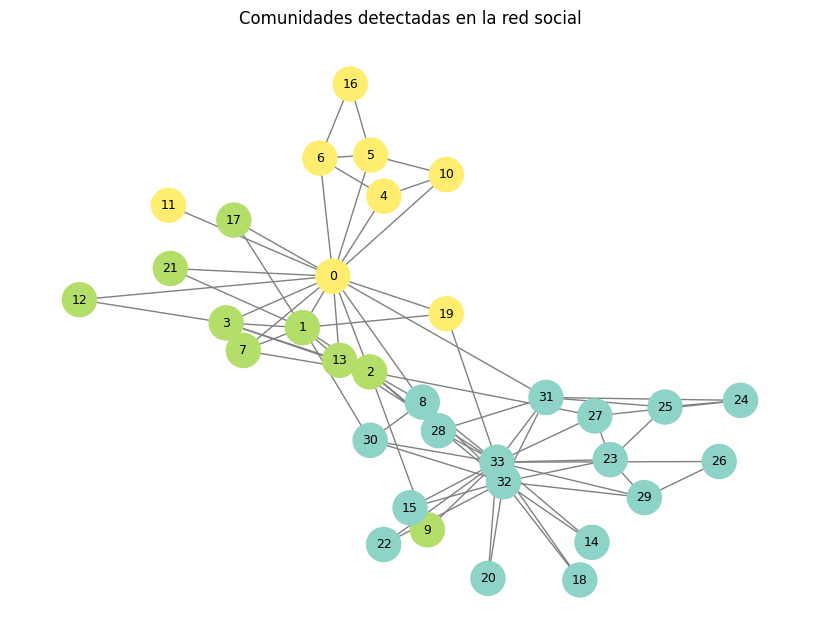

In [12]:
# Colorear nodos segun la comunidad a la que pertenecen
mapa_colores = {}
for i, comunidad in enumerate(communities):
    for nodo in comunidad:
        mapa_colores[nodo] = i

node_colors = [mapa_colores[n] for n in G.nodes()]

plt.figure()
nx.draw(
    G,
    pos,
    with_labels=True,
    node_color=node_colors,
    cmap=plt.cm.Set3,
    edge_color="gray",
    node_size=600,
    font_size=9
)
plt.title("Comunidades detectadas en la red social")
plt.show()

Cada color es una comunidad distinta. Hay entonces 3 comunidades.

In [13]:
for c in communities:
    print(len(c), list(c))

17 [8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33]
9 [1, 2, 3, 7, 9, 12, 13, 17, 21]
8 [0, 16, 19, 4, 5, 6, 10, 11]


Aplicando el algoritmo de particion codiciosa, se obtuvieron las siguientes comunidades:

Tamaño 17: {8, 14, 15, 18, 20, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33}

Tamaño 9: {1, 2, 3, 7, 9, 12, 13, 17, 21}

Tamaño 8: {0, 16, 19, 4, 5, 6, 10, 11}

No se encontraron comunidades de tamaño 3 ni 4. Todas las comunidades detectadas tienen 5 o más nodos, indicando grupos de alta conexion dentro de la red.